<a href="https://colab.research.google.com/github/rachealA924/Formative3-Probability-Distributions-Assignment_Group22/blob/main/Formative3_Probability_Distributions_Assignment_Group22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('GaltonFamilies.csv')

# Inspect it
print(df.head())
print("\nColumns:", df.columns.tolist())
print("\nShape:", df.shape)
print("\nBasic Stats:\n", df.describe())

FileNotFoundError: [Errno 2] No such file or directory: 'GaltonFamilies.csv'

In [ ]:
mother_heights = df['mother'].dropna().values
child_heights = df['childHeight'].dropna().values

# unlabeled dataset the mixture
all_heights = np.concatenate([mother_heights, child_heights])

print(f"Total data points: {len(all_heights)}")
print(f"Global mean (the 'naive split' line): {all_heights.mean():.2f}")

# Visualize the mixture
plt.figure(figsize=(10, 5))
plt.hist(all_heights, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(all_heights.mean(), color='red', linestyle='--', label=f'Global Mean = {all_heights.mean():.2f}"')
plt.title('Mixed Height Distribution (No Labels)')
plt.xlabel('Height (inches)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

In [ ]:
from scipy.stats import norm

def gaussian_pdf(x, mu, sigma):
    "Probability density of x under a Gaussian with given mu and sigma."
    return norm.pdf(x, mu, sigma)


def initialize_params(data, seed=42):
    "Randomly initialize the two Gaussian components."
    np.random.seed(seed)

    idx = np.random.choice(len(data), 2, replace=False)
    mu1, mu2 = data[idx[0]], data[idx[1]]
    sigma1 = sigma2 = np.std(data)
    pi1 = pi2 = 0.5
    return mu1, mu2, sigma1, sigma2, pi1, pi2


def e_step(data, mu1, mu2, sigma1, sigma2, pi1, pi2):
    #compute responsibilities
    """
    r1[i] = probability that point i belongs to component 1 (Children)
    r2[i] = probability that point i belongs to component 2 (Mothers)"""

    # Weighted likelihoods
    p1 = pi1 * gaussian_pdf(data, mu1, sigma1)
    p2 = pi2 * gaussian_pdf(data, mu2, sigma2)
    total = p1 + p2

    r1 = p1 / total
    r2 = p2 / total
    return r1, r2


def m_step(data, r1, r2):
    "update parameters using the responsibilities."
    N1 = np.sum(r1)
    N2 = np.sum(r2)

    # Update means
    mu1 = np.sum(r1 * data) / N1
    mu2 = np.sum(r2 * data) / N2

    # Update variances
    sigma1 = np.sqrt(np.sum(r1 * (data - mu1)**2) / N1)
    sigma2 = np.sqrt(np.sum(r2 * (data - mu2)**2) / N2)

    # Update mixing coefficients
    pi1 = N1 / len(data)
    pi2 = N2 / len(data)

    return mu1, mu2, sigma1, sigma2, pi1, pi2


def compute_log_likelihood(data, mu1, mu2, sigma1, sigma2, pi1, pi2):
    "Overall log-likelihood of the data under the current model."
    p1 = pi1 * gaussian_pdf(data, mu1, sigma1)
    p2 = pi2 * gaussian_pdf(data, mu2, sigma2)
    return np.sum(np.log(p1 + p2))


def run_em(data, max_iter=100, tol=1e-6):
    "Full EM loop with convergence check and tracking table."
    mu1, mu2, sigma1, sigma2, pi1, pi2 = initialize_params(data)

    print(f"{'Iter':<6} {'μ1 (Children)':<16} {'μ2 (Mothers)':<15} {'σ1':<10} {'σ2':<10} {'π1':<8} {'π2':<8} {'Log-Likelihood'}")
    print("-" * 90)

    log_likelihoods = []
    history = []

    for i in range(max_iter):
        ll = compute_log_likelihood(data, mu1, mu2, sigma1, sigma2, pi1, pi2)
        log_likelihoods.append(ll)
        history.append((i, mu1, mu2, sigma1, sigma2, pi1, pi2, ll))

        # Print first 3 iterations (for the presentation table)
        if i < 3:
            print(f"{i:<6} {mu1:<16.4f} {mu2:<15.4f} {sigma1**2:<10.4f} {sigma2**2:<10.4f} {pi1:<8.4f} {pi2:<8.4f} {ll:.4f}")

        # E-step
        r1, r2 = e_step(data, mu1, mu2, sigma1, sigma2, pi1, pi2)

        # M-step
        mu1_new, mu2_new, sigma1_new, sigma2_new, pi1_new, pi2_new = m_step(data, r1, r2)

        # Check convergence
        if abs(mu1_new - mu1) < tol and abs(mu2_new - mu2) < tol:
            mu1, mu2, sigma1, sigma2, pi1, pi2 = mu1_new, mu2_new, sigma1_new, sigma2_new, pi1_new, pi2_new
            print(f"\n✅ Converged at iteration {i+1}")
            break

        mu1, mu2, sigma1, sigma2, pi1, pi2 = mu1_new, mu2_new, sigma1_new, sigma2_new, pi1_new, pi2_new

    return mu1, mu2, sigma1, sigma2, pi1, pi2, log_likelihoods


# Run it!
mu1, mu2, sigma1, sigma2, pi1, pi2, log_likelihoods = run_em(all_heights)

print(f"\nFinal Parameters:")
print(f"  Children  → μ = {mu1:.2f}, σ = {sigma1:.2f}, π = {pi1:.4f}")
print(f"  Mothers   → μ = {mu2:.2f}, σ = {sigma2:.2f}, π = {pi2:.4f}")

NameError: name 'all_heights' is not defined

In [ ]:
def classify_height(test_height, mu1, mu2, sigma1, sigma2, pi1, pi2):
    """
    Given a height, compute posterior probabilities for each group.
    P(Child | height) and P(Mother | height) using Bayes' theorem.
    """
    p_child  = pi1 * gaussian_pdf(test_height, mu1, sigma1)
    p_mother = pi2 * gaussian_pdf(test_height, mu2, sigma2)
    total    = p_child + p_mother

    prob_child  = p_child  / total
    prob_mother = p_mother / total

    print(f"\n🔍 Test Height: {test_height} inches")
    print(f"   P(Child  | height) = {prob_child:.4f}  ({prob_child*100:.1f}%)")
    print(f"   P(Mother | height) = {prob_mother:.4f}  ({prob_mother*100:.1f}%)")

    label = "Child" if prob_child > prob_mother else "Mother"
    print(f"   → Most likely classification: {label}")

# Test
classify_height(64, mu1, mu2, sigma1, sigma2, pi1, pi2)


🔍 Test Height: 64 inches
   P(Child  | height) = 0.0648  (6.5%)
   P(Mother | height) = 0.9352  (93.5%)
   → Most likely classification: Mother


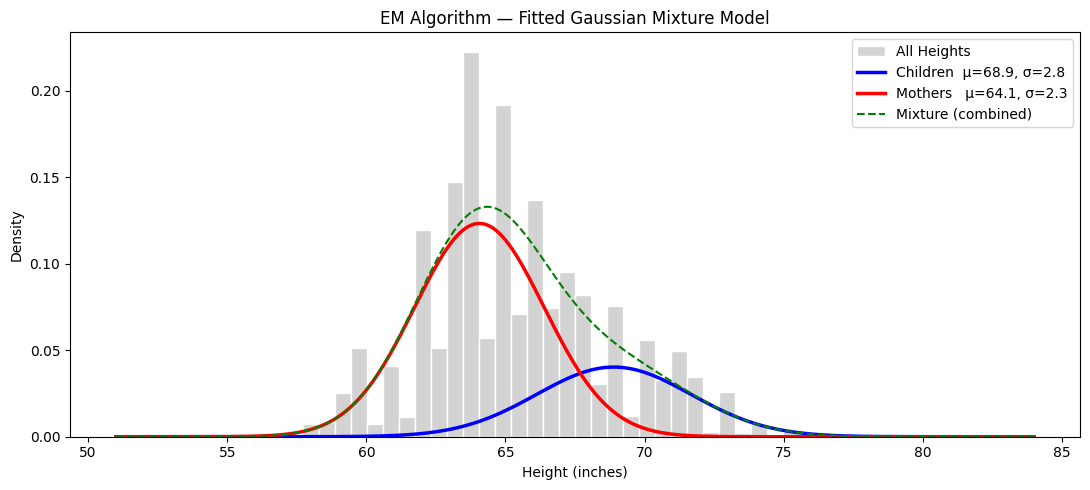

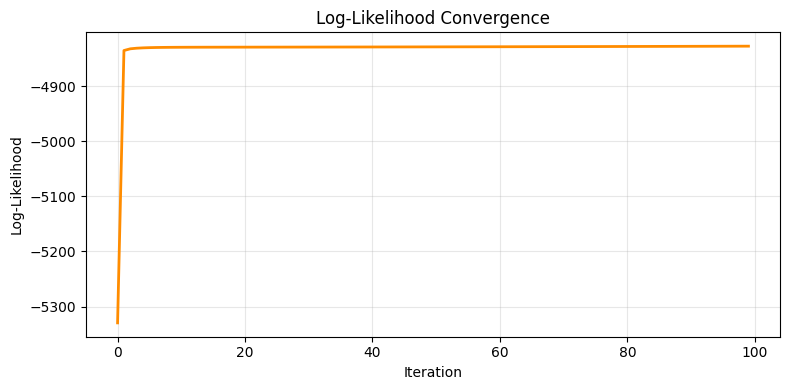

In [ ]:
# Plot 1: Fitted Gaussians over the data
x_range = np.linspace(all_heights.min() - 5, all_heights.max() + 5, 300)

plt.figure(figsize=(11, 5))
plt.hist(all_heights, bins=40, density=True, color='lightgray', edgecolor='white', label='All Heights')
plt.plot(x_range, pi1 * gaussian_pdf(x_range, mu1, sigma1), 'b-', linewidth=2.5, label=f'Children  μ={mu1:.1f}, σ={sigma1:.1f}')
plt.plot(x_range, pi2 * gaussian_pdf(x_range, mu2, sigma2), 'r-', linewidth=2.5, label=f'Mothers   μ={mu2:.1f}, σ={sigma2:.1f}')
plt.plot(x_range, pi1 * gaussian_pdf(x_range, mu1, sigma1) + pi2 * gaussian_pdf(x_range, mu2, sigma2),
         'g--', linewidth=1.5, label='Mixture (combined)')
plt.title('EM Algorithm — Fitted Gaussian Mixture Model')
plt.xlabel('Height (inches)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2: Log-Likelihood over iterations
plt.figure(figsize=(8, 4))
plt.plot(log_likelihoods, color='darkorange', linewidth=2)
plt.title('Log-Likelihood Convergence')
plt.xlabel('Iteration')
plt.ylabel('Log-Likelihood')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

PART2: BAYESIAN PROBABILITY

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/IMDB Dataset.csv")

print(df.head())
print("\nShape:", df.shape)
print("\nSentiment Counts:")
print(df["sentiment"].value_counts())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Shape: (50000, 2)

Sentiment Counts:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
keywords = [
    "excellent",
    "great",
    "amazing",
    "wonderful"
]

In [ ]:
def compute_prior(df):
    positive_reviews = (df["sentiment"] == "positive").sum()
    total_reviews = len(df)
    return positive_reviews / total_reviews


def compute_likelihood(df, keyword):
    positive_reviews = df[df["sentiment"] == "positive"]

    keyword_count = (
        positive_reviews["review"]
        .str.lower()
        .str.contains(keyword, na=False)
        .sum()
    )

    return keyword_count / len(positive_reviews)


def compute_marginal(df, keyword):
    keyword_count = (
        df["review"]
        .str.lower()
        .str.contains(keyword, na=False)
        .sum()
    )

    return keyword_count / len(df)


def compute_posterior(prior, likelihood, marginal):
    return (likelihood * prior) / marginal

In [ ]:
def classify_keyword(df, keyword):

    prior = compute_prior(df)

    likelihood = compute_likelihood(df, keyword)

    marginal = compute_marginal(df, keyword)

    posterior = compute_posterior(
        prior,
        likelihood,
        marginal
    )

    print("\n" + "=" * 50)
    print(f"Keyword: {keyword}")
    print("=" * 50)

    print(f"P(Positive) = {prior:.4f}")
    print(f"P({keyword}|Positive) = {likelihood:.4f}")
    print(f"P({keyword}) = {marginal:.4f}")
    print(f"P(Positive|{keyword}) = {posterior:.4f}")

    print(
        f"\n→ A review containing '{keyword}' "
        f"has a {posterior*100:.2f}% probability "
        f"of being positive."
    )

    return [
        keyword,
        prior,
        likelihood,
        marginal,
        posterior
    ]

In [ ]:
def classify_keyword(df, keyword):

    prior = compute_prior(df)
    likelihood = compute_likelihood(df, keyword)
    marginal = compute_marginal(df, keyword)
    posterior = compute_posterior(
        prior,
        likelihood,
        marginal
    )

    print(f"\nKeyword: {keyword}")
    print(f"P(Positive) = {prior:.4f}")
    print(f"P({keyword}|Positive) = {likelihood:.4f}")
    print(f"P({keyword}) = {marginal:.4f}")
    print(f"P(Positive|{keyword}) = {posterior:.4f}")

    return [
        keyword,
        prior,
        likelihood,
        marginal,
        posterior
    ]

In [ ]:
results = []

for word in keywords:
    results.append(classify_keyword(df, word))


Keyword: excellent
P(Positive) = 0.5000
P(excellent|Positive) = 0.1174
P(excellent) = 0.0725
P(Positive|excellent) = 0.8099

Keyword: great
P(Positive) = 0.5000
P(great|Positive) = 0.3712
P(great) = 0.2761
P(Positive|great) = 0.6722

Keyword: amazing
P(Positive) = 0.5000
P(amazing|Positive) = 0.0740
P(amazing) = 0.0496
P(Positive|amazing) = 0.7463

Keyword: wonderful
P(Positive) = 0.5000
P(wonderful|Positive) = 0.1066
P(wonderful) = 0.0650
P(Positive|wonderful) = 0.8203


In [ ]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Keyword",
        "P(Positive)",
        "P(keyword|Positive)",
        "P(keyword)",
        "P(Positive|keyword)"
    ]
)

print(results_df)

     Keyword  P(Positive)  P(keyword|Positive)  P(keyword)  \
0  excellent          0.5              0.11744     0.07250   
1      great          0.5              0.37124     0.27614   
2    amazing          0.5              0.07400     0.04958   
3  wonderful          0.5              0.10660     0.06498   

   P(Positive|keyword)  
0             0.809931  
1             0.672195  
2             0.746269  
3             0.820252  


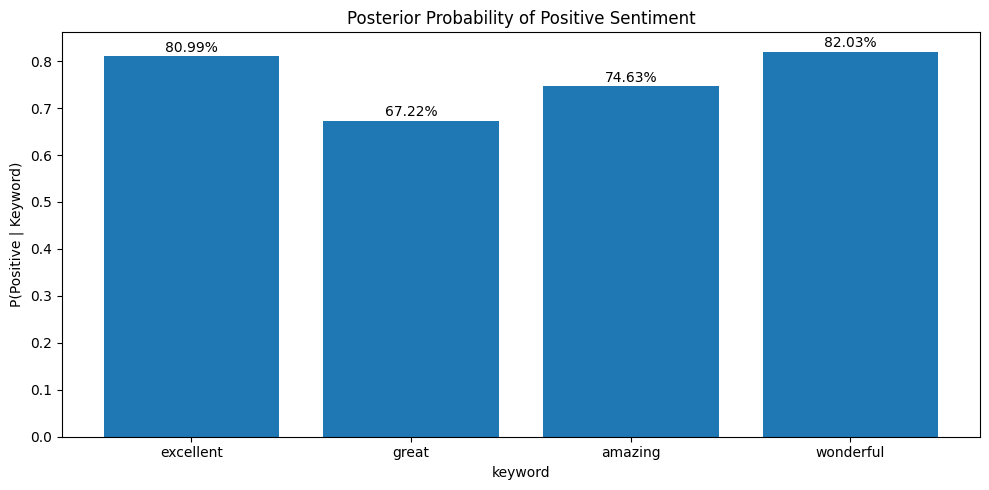

In [ ]:
plt.figure(figsize=(10, 5))

bars = plt.bar(
    results_df["Keyword"],
    results_df["P(Positive|keyword)"]
)

plt.title("Posterior Probability of Positive Sentiment")
plt.xlabel("keyword")
plt.ylabel("P(Positive | Keyword)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.2%}",
        ha='center'
    )

plt.tight_layout()
plt.show()

# Part 3 in pdf on Github

# for part 4 Gradient Descent in code


Iteration 1 complete.
  m: [-5.5 -9.3]
  b: [-0.2 -0.2]
Iteration 2 complete.
  m: [ 46.84 123.48]
  b: [15.78 15.78]
Iteration 3 complete.
  m: [ -568.742 -1436.878]
  b: [-170.22 -170.22]


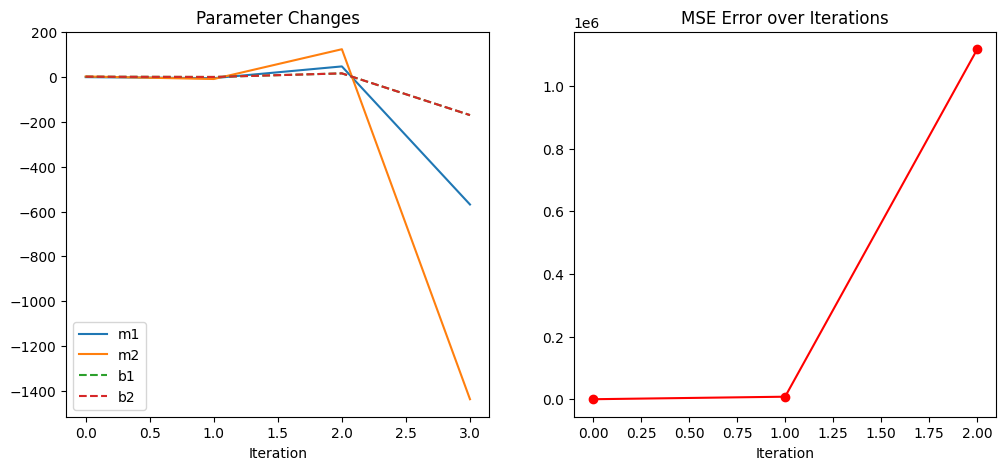

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Initial values from your Part 3
m = np.array([-1.0, 2.0])  #
b = np.array([1.0, 1.0])
learning_rate = 0.1

# Data
X = np.array([[1, 3], [4, 10]])
y = np.array([5, 6])

# Storage for plotting
m_history = [m.copy()]
b_history = [b.copy()]
mse_history = []

def compute_mse(y_pred, y):
    return np.mean((y_pred - y)**2)

# Perform 3 iterations
for i in range(3):
    # 1. Predictions
    y_pred = np.dot(X, m) + b

    # 2. Error
    error = y_pred - y
    mse_history.append(compute_mse(y_pred, y))

    # 3. Gradients
    n = len(y)
    m_gradient = (2/n) * np.dot(X.T, error)
    b_gradient = (2/n) * np.sum(error)

    # 4. Update
    m = m - learning_rate * m_gradient
    b = b - learning_rate * b_gradient

    # Store
    m_history.append(m.copy())
    b_history.append(b.copy())

    print(f"Iteration {i+1} complete.")
    print(f"  m: {m}")
    print(f"  b: {b}")

# Plotting
m_history = np.array(m_history)
b_history = np.array(b_history)

plt.figure(figsize=(12, 5))

# Plot Parameters
plt.subplot(1, 2, 1)
plt.plot(m_history, label=['m1', 'm2'])
plt.plot(b_history, label=['b1', 'b2'], linestyle='--')
plt.title("Parameter Changes")
plt.xlabel("Iteration")
plt.legend()

# Plot Error
plt.subplot(1, 2, 2)
plt.plot(mse_history, color='red', marker='o')
plt.title("MSE Error over Iterations")
plt.xlabel("Iteration")

plt.show()
